# Training

We train a Transformer text encoder built from scratch (our own word-level tokenizer, randomly-initialised embeddings, hand-written multi-head self-attention) with two contrastive objectives, InfoNCE and Triplet loss, on MS MARCO query–passage pairs. At the end we compare it against a fine-tuned DistilBERT.

In [1]:
import json
import sys
from pathlib import Path

import torch
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from train import train
from vocab import Vocab
from transformer_encoder import TransformerEncoder
from search import get_device
from loss import InfoNCELoss, TripletLoss

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

## Tokenizer

Our word-level tokenizer lowercases the text, splits on word characters, and builds a frequency vocabulary from the training pairs. The two reserved ids are `<pad>` and `<unk>`.

In [2]:
with open(PROJECT_ROOT / "data/pairs/train.json", encoding="utf-8") as f:
    train_pairs = json.load(f)

vocab_texts = []
for item in train_pairs:
    vocab_texts.extend((item["query"], item["positive"], item["negative"]))

vocab = Vocab.build(vocab_texts)
print(f"Vocabulary size: {len(vocab)}")

example = "What is byte pair encoding?"
print(f"\nText : {example}")
print(f"Ids  : {vocab.encode(example)}")

Vocabulary size: 30000

Text : What is byte pair encoding?
Ids  : [23, 6, 9061, 2448, 10874]


## Model sanity check

The encoder returns one L2-normalised vector per input, so every embedding norm is close to 1.

In [3]:
device = get_device()
print("Device:", device)

model = TransformerEncoder(vocab).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,}")

texts = [
    "What is information retrieval?",
    "Information retrieval is the task of finding relevant documents.",
]
batch = model.tokenize(texts)
with torch.no_grad():
    emb = model(batch["input_ids"].to(device), batch["attention_mask"].to(device))

print("Embedding shape:", tuple(emb.shape))
print("Norms:", [round(n, 3) for n in torch.norm(emb, dim=1).tolist()])

Device: cuda
Parameters: 8,800,256


Embedding shape: (2, 256)
Norms: [1.0, 1.0]


## Loss sanity check

On random embeddings the InfoNCE loss sits near `log(2B)`, the cross-entropy of a uniform choice over the `2B` in-batch candidates, and the Triplet loss sits near its margin since positive and negative similarities are both close to zero.

In [4]:
B, D = 8, 256
q = torch.nn.functional.normalize(torch.randn(B, D), dim=1)
pos = torch.nn.functional.normalize(torch.randn(B, D), dim=1)
neg = torch.nn.functional.normalize(torch.randn(B, D), dim=1)

infonce = InfoNCELoss(scale=20.0)
triplet = TripletLoss(margin=0.2)

print(f"InfoNCE on random embeddings: {infonce(q, pos, neg).item():.4f}")
print(f"Triplet on random embeddings: {triplet(q, pos, neg).item():.4f}")
print(f"log(2B) reference:            {torch.log(torch.tensor(2.0 * B)).item():.4f}")

InfoNCE on random embeddings: 2.8272
Triplet on random embeddings: 0.1506
log(2B) reference:            2.7726


## Train with InfoNCE

`train(model_type="transformer_scratch")` builds the vocabulary from the training pairs, initialises the Transformer from random weights, and trains it. Lower `max_train_samples` or `epochs` if you are training on CPU.

In [5]:
history_infonce = train(
    epochs=6,
    batch_size=64,
    lr=3e-4,
    loss_type="infonce",
    model_type="transformer_scratch",
    max_val_samples=1000,
    log_every=100,
)

Built vocabulary of 30000 tokens


epoch 1 | step 100/704 | loss 2.8028


epoch 1 | step 200/704 | loss 2.3734


epoch 1 | step 300/704 | loss 2.2865


epoch 1 | step 400/704 | loss 2.1962


...

epoch 6 | step 400/704 | loss 1.1180


epoch 6 | step 500/704 | loss 1.1616


epoch 6 | step 600/704 | loss 1.1422


epoch 6 | step 700/704 | loss 1.1448


[val] epoch 6: recall@1=0.5420, recall@5=0.7050, recall@10=0.7530, mrr=0.6172


## Train with Triplet loss

In [6]:
history_triplet = train(
    epochs=6,
    batch_size=64,
    lr=3e-4,
    loss_type="triplet",
    model_type="transformer_scratch",
    max_val_samples=1000,
    log_every=100,
)

Built vocabulary of 30000 tokens


epoch 1 | step 100/704 | loss 0.1587


epoch 1 | step 200/704 | loss 0.1474


epoch 1 | step 300/704 | loss 0.1475


epoch 1 | step 400/704 | loss 0.1463


...

epoch 6 | step 400/704 | loss 0.0722


epoch 6 | step 500/704 | loss 0.0757


epoch 6 | step 600/704 | loss 0.0774


epoch 6 | step 700/704 | loss 0.0760


[val] epoch 6: recall@1=0.1110, recall@5=0.2230, recall@10=0.2770, mrr=0.1702


## Training loss curves

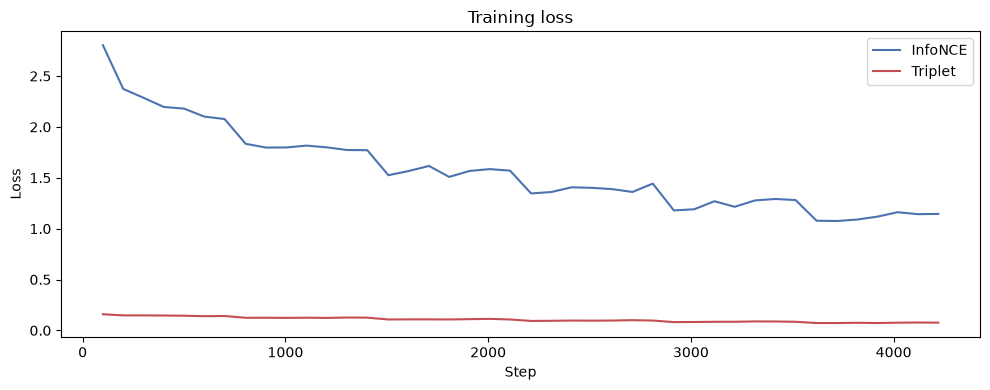

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_infonce["step"], history_infonce["train_loss"], color="#4C72B0", label="InfoNCE", linewidth=1.5)
ax.plot(history_triplet["step"], history_triplet["train_loss"], color="#C44E52", label="Triplet", linewidth=1.5)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training loss")
ax.legend()
plt.tight_layout()
plt.savefig("training_loss.png", dpi=120)
plt.show()

## Validation metrics over epochs

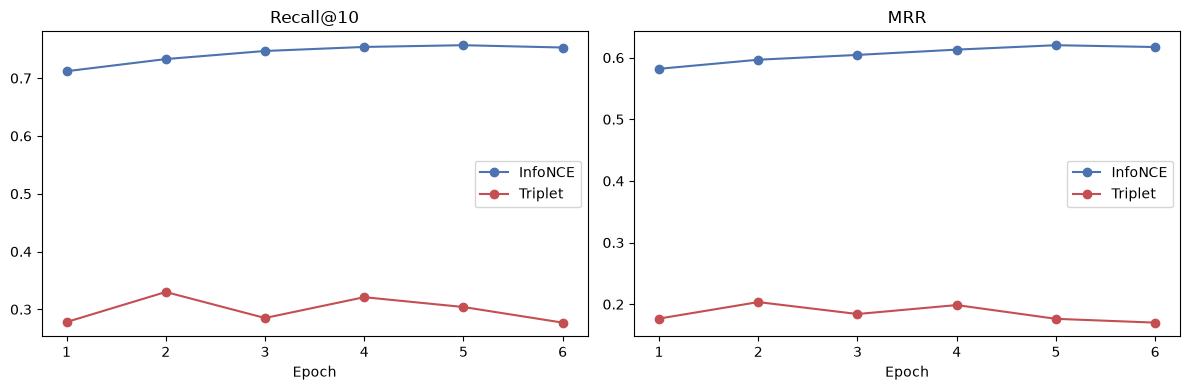

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for history, label, color in [(history_infonce, "InfoNCE", "#4C72B0"), (history_triplet, "Triplet", "#C44E52")]:
    epochs_x = [v["epoch"] for v in history["val"]]
    for ax, metric in zip(axes, ["recall@10", "mrr"]):
        ax.plot(epochs_x, [v[metric] for v in history["val"]], marker="o", color=color, label=label)

for ax, title in zip(axes, ["Recall@10", "MRR"]):
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_xticks([v["epoch"] for v in history_infonce["val"]])
    ax.legend()

plt.tight_layout()
plt.savefig("val_metrics.png", dpi=120)
plt.show()

## Summary

In [9]:
print(f"{'Metric':<12}{'InfoNCE':>10}{'Triplet':>10}")
print("-" * 32)
for metric in ["recall@1", "recall@5", "recall@10", "mrr"]:
    print(f"{metric:<12}{history_infonce['val'][-1][metric]:>10.4f}{history_triplet['val'][-1][metric]:>10.4f}")

Metric         InfoNCE   Triplet
--------------------------------
recall@1        0.5420    0.1110
recall@5        0.7050    0.2230
recall@10       0.7530    0.2770
mrr             0.6172    0.1702


## Comparison with DistilBERT

For reference we also fine-tuned a pretrained DistilBERT with the same `train()` function (`model_type="transformer"`). Its training is far heavier, so here we load its saved validation history rather than re-running it, and compare the best InfoNCE checkpoints.

In [10]:
with open(CHECKPOINT_DIR / "history_infonce.json") as f:
    distilbert_infonce = json.load(f)

print(f"{'Metric':<12}{'Transformer':>14}{'DistilBERT':>14}")
print("-" * 40)
for metric in ["recall@1", "recall@5", "recall@10", "mrr"]:
    t = history_infonce["val"][-1][metric]
    d = distilbert_infonce["val"][-1][metric]
    print(f"{metric:<12}{t:>14.4f}{d:>14.4f}")

Metric         Transformer    DistilBERT
----------------------------------------
recall@1            0.5420        0.9040
recall@5            0.7050        0.9730
recall@10           0.7530        0.9770
mrr                 0.6172        0.9351
